# Notebook 1 — Classificação

##Aluno: Pedro Pereira Dutra - RA: 24101026
## Dataset: Sleep Health & Daily Performance
## **Fonte:** https://www.kaggle.com/datasets/mohankrishnathalla/sleep-health-and-daily-performance-dataset
###Conteúdo:
###Este conjunto de dados contém 100.000 registros sintéticos de pacientes, projetados para uma análise abrangente da saúde do sono, previsão de risco de distúrbios e modelagem do desempenho cognitivo. Cada registro captura um instantâneo diário completo: medições da arquitetura do sono, comportamentos de estilo de vida, estado psicológico e resultados cognitivos do dia seguinte.
## Objetivo:
## Prever o risco de distúrbio do sono que seriam :

###Dificuldade para dormir, acordar várias vezes, sonolência excessiva durante o dia, ou comportamentos anormais (ronco, movimentos)

###Com base em hábitos de saúde, sono e estilo de vida.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True) #para tirar os avisos do pandas

from google.colab import drive
drive.mount('/content/drive')

df = pd.read_csv('/content/drive/MyDrive/sleep_health_dataset.csv')
df.head()

Mounted at /content/drive


,person_id,age,gender,occupation,bmi,country,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,...,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,season,day_type,cognitive_performance_score,sleep_disorder_risk,felt_rested
0,1,29,Female,Driver,25.7,Japan,6.19,6.6,22.5,19.3,...,63,0,0,20.1,1.84,Autumn,Weekday,73.4,Healthy,0
1,2,55,Female,Software Engineer,22.0,USA,8.32,6.9,26.9,14.9,...,52,1,0,18.0,0.13,Winter,Weekend,99.4,Healthy,1
2,3,42,Male,Nurse,25.0,India,3.74,1.0,20.2,16.2,...,72,0,1,17.9,1.67,Spring,Weekend,2.5,Severe,0
3,4,37,Female,Student,29.5,India,6.79,6.4,17.7,17.7,...,71,0,0,19.1,2.37,Summer,Weekend,67.8,Healthy,0
4,5,23,Male,Lawyer,23.6,Spain,5.02,3.2,23.3,18.3,...,71,0,0,19.7,1.26,Summer,Weekday,38.1,Mild,0


## Análise Exploratória dos Dados:

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   gender                       100000 non-null  object 
 3   occupation                   100000 non-null  object 
 4   bmi                          100000 non-null  float64
 5   country                      100000 non-null  object 
 6   sleep_duration_hrs           100000 non-null  float64
 7   sleep_quality_score          100000 non-null  float64
 8   rem_percentage               100000 non-null  float64
 9   deep_sleep_percentage        100000 non-null  float64
 10  sleep_latency_mins           100000 non-null  int64  
 11  wake_episodes_per_night      100000 non-null  int64  
 12  caffeine_mg_before_bed       100000 non-null  int64  
 13  

In [4]:
print(df['sleep_disorder_risk'].value_counts())
print()
print(df['sleep_disorder_risk'].value_counts(normalize=True) * 100)

sleep_disorder_risk
Healthy     54156
Mild        33479
Moderate     8299
Severe       4066
Name: count, dtype: int64

sleep_disorder_risk
Healthy     54.156
Mild        33.479
Moderate     8.299
Severe       4.066
Name: proportion, dtype: float64


In [5]:
df.describe()

,person_id,age,bmi,sleep_duration_hrs,sleep_quality_score,rem_percentage,deep_sleep_percentage,sleep_latency_mins,wake_episodes_per_night,caffeine_mg_before_bed,...,nap_duration_mins,stress_score,work_hours_that_day,heart_rate_resting_bpm,sleep_aid_used,shift_work,room_temperature_celsius,weekend_sleep_diff_hrs,cognitive_performance_score,felt_rested
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,...,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,34.706870,26.289673,6.423986,4.871144,20.243968,20.253375,19.836810,3.346610,38.849500,...,14.936840,5.733285,7.134059,66.57017,0.561610,0.084420,20.538093,1.200634,59.227295,0.390120
std,28867.657797,11.036373,4.479578,1.274627,1.506517,3.411354,4.251096,7.584343,1.920877,69.395818,...,21.387567,1.619194,3.482878,7.22821,0.496192,0.278018,2.897565,0.786667,22.249665,0.487779
min,1.000000,18.000000,16.000000,3.000000,1.000000,10.000000,5.000000,1.000000,0.000000,0.000000,...,0.000000,1.000000,0.000000,45.00000,0.000000,0.000000,15.000000,-1.000000,0.000000,0.000000
25%,25000.750000,26.000000,23.200000,5.530000,3.800000,18.000000,17.400000,14.000000,2.000000,0.000000,...,0.000000,4.800000,4.700000,62.00000,0.000000,0.000000,18.500000,0.670000,44.200000,0.000000
50%,50000.500000,33.000000,26.300000,6.360000,4.900000,20.300000,20.300000,19.000000,3.000000,0.000000,...,0.000000,5.800000,7.400000,67.00000,1.000000,0.000000,20.500000,1.200000,60.400000,0.000000
75%,75000.250000,42.000000,29.300000,7.270000,6.000000,22.600000,23.200000,25.000000,5.000000,80.000000,...,30.000000,6.800000,9.700000,71.00000,1.000000,0.000000,22.500000,1.740000,75.800000,1.000000
max,100000.000000,69.000000,45.000000,10.500000,10.000000,30.000000,30.000000,58.000000,8.000000,400.000000,...,116.000000,10.000000,18.000000,99.00000,1.000000,1.000000,28.000000,3.000000,100.000000,1.000000


In [6]:
df.isnull().sum() #ver se tem valores nulos na tabela

,0
person_id,0
age,0
gender,0
occupation,0
bmi,0
country,0
sleep_duration_hrs,0
sleep_quality_score,0
rem_percentage,0
deep_sleep_percentage,0


###Visualizações das variáveis:

###1- Distribuição da variável alvo

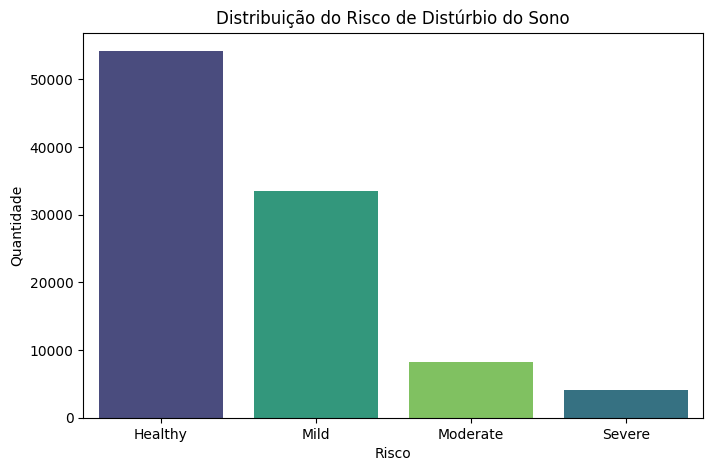

In [7]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='sleep_disorder_risk',
              hue='sleep_disorder_risk',
              order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis',
              legend=False)
plt.title('Distribuição do Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Quantidade')
plt.show()

### Interpretação — Distribuição da Variável Alvo

O gráfico mostra a distribuição das 4 classes da variável alvo `sleep_disorder_risk`.

O dataset apresenta um claro desbalanceamento entre as classes:
- Healthy: 54.156 registros (54%)
- Mild: 33.479 registros (33%)
- Moderate: 8.299 registros (8%)
- Severe: 4.066 registros (4%)

Esse desbalanceamento foi analisado na etapa de modelagem, onde foi
testado o uso do SMOTE para equilibrar as classes. Porém, o balanceamento
piorou o desempenho de todos os modelos, optando-se por manter os dados
originais.

###2- Distribuição do risco de distúrbio de sono por País:

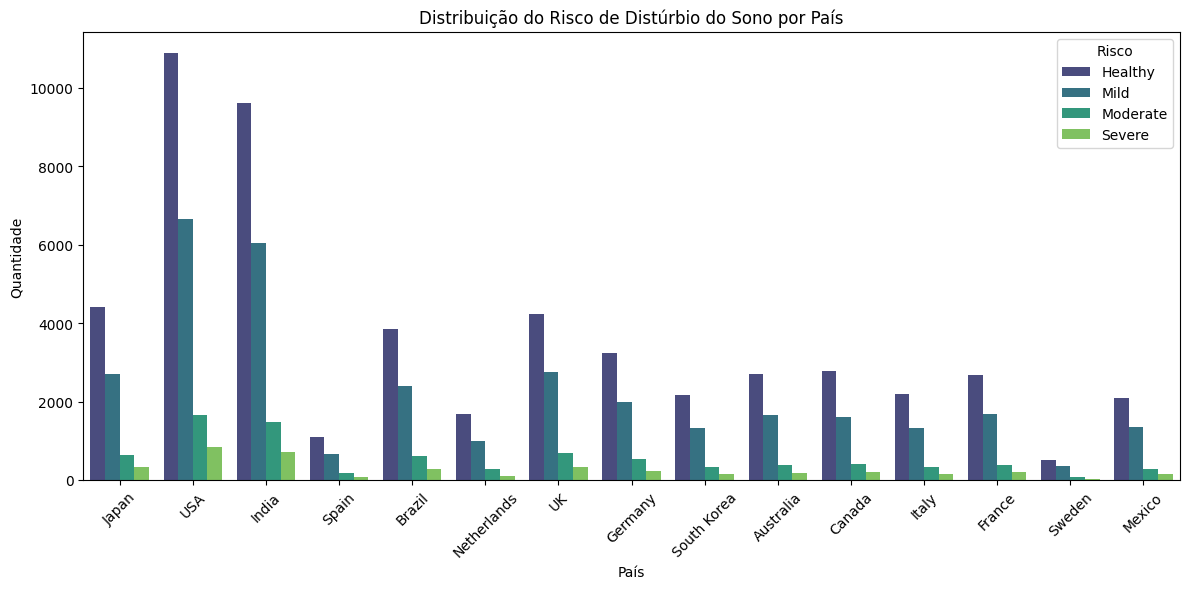

In [8]:
plt.figure(figsize=(12, 6)) #Cria uma figura (tela em branco para o gráfico) e o figsize define o tamanho
sns.countplot(data=df, x='country', #Chama o seaborn para fazer um gráfico de barras c.data=df diz qual dataset usar e x='country' diz que os países vão ficar no eixo horizontal.
              hue='sleep_disorder_risk', # hue divide cada barra de país em 4 barrinhas coloridas, uma para cada categoria de risco
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por País')
plt.xlabel('País')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.xticks(rotation=45) #rotaciona os nomes dos países em 45 graus pra eles não se sobreporem
plt.tight_layout() #ajusta as margens do gráfico
plt.show()

### Interpretação — Distribuição por País

O gráfico mostra a distribuição do risco de distúrbio do sono entre os 15 países presentes no dataset.

EUA e Índia se destacam com o maior volume de registros em todas as categorias,
o que reflete simplesmente uma maior representatividade desses países no dataset
e não necessariamente um risco maior de distúrbio do sono.

Proporcionalmente, o padrão Healthy > Mild > Moderate > Severe se mantém
consistente em todos os países, sugerindo que o país de origem não é um fator
determinante para o risco de distúrbio do sono neste dataset.

Isso indica que a variável `country` pode ter baixo poder preditivo para o modelo,
e poderá ser removida ou ter sua importância reduzida no pré-processamento.

###3- Distribuição do risco de distúrbio de sono por Gênero:

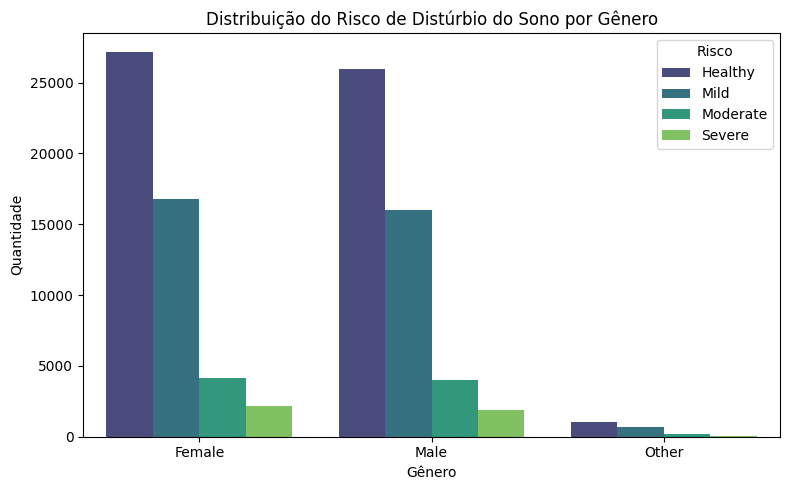

In [9]:
plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='gender',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Gênero')
plt.xlabel('Gênero')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Distribuição por Gênero

O gráfico mostra que o padrão Healthy > Mild > Moderate > Severe
se repete de forma similar entre todos os gêneros (Female, Male, Other),
sem diferença proporcional significativa.

Isso sugere que o gênero isoladamente não é um fator determinante
para o risco de distúrbio do sono neste dataset.

###4-Distribuição do risco de distúrbio de sono por Faixa Etária:

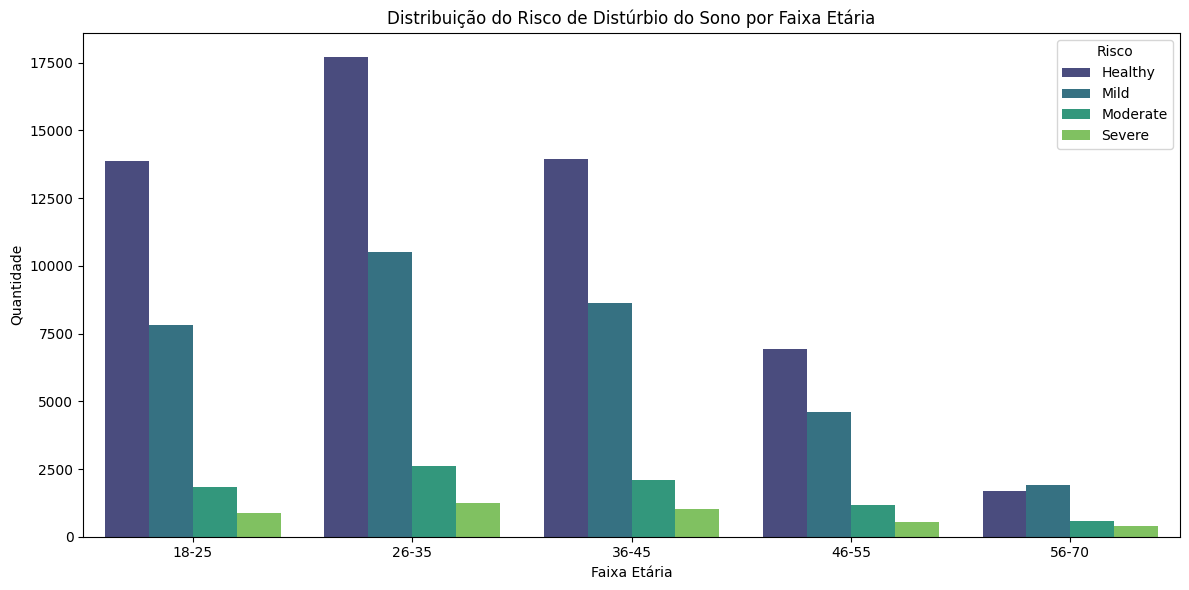

In [10]:
df['faixa_etaria'] = pd.cut(df['age'],
                             bins=[17, 25, 35, 45, 55, 70],
                             labels=['18-25', '26-35', '36-45', '46-55', '56-70'])

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='faixa_etaria',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Faixa Etária')
plt.xlabel('Faixa Etária')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Distribuição por Faixa Etária

A faixa etária de 26-35 anos concentra o maior volume de registros no dataset.
Proporcionalmente, os casos Moderate e Severe aumentam nas faixas mais velhas
(46-55 e 56-70), sugerindo que a idade pode ser um fator de risco para
distúrbios do sono mais graves.

###5-Distribuição do risco de distúrbio de sono por Ocupação:

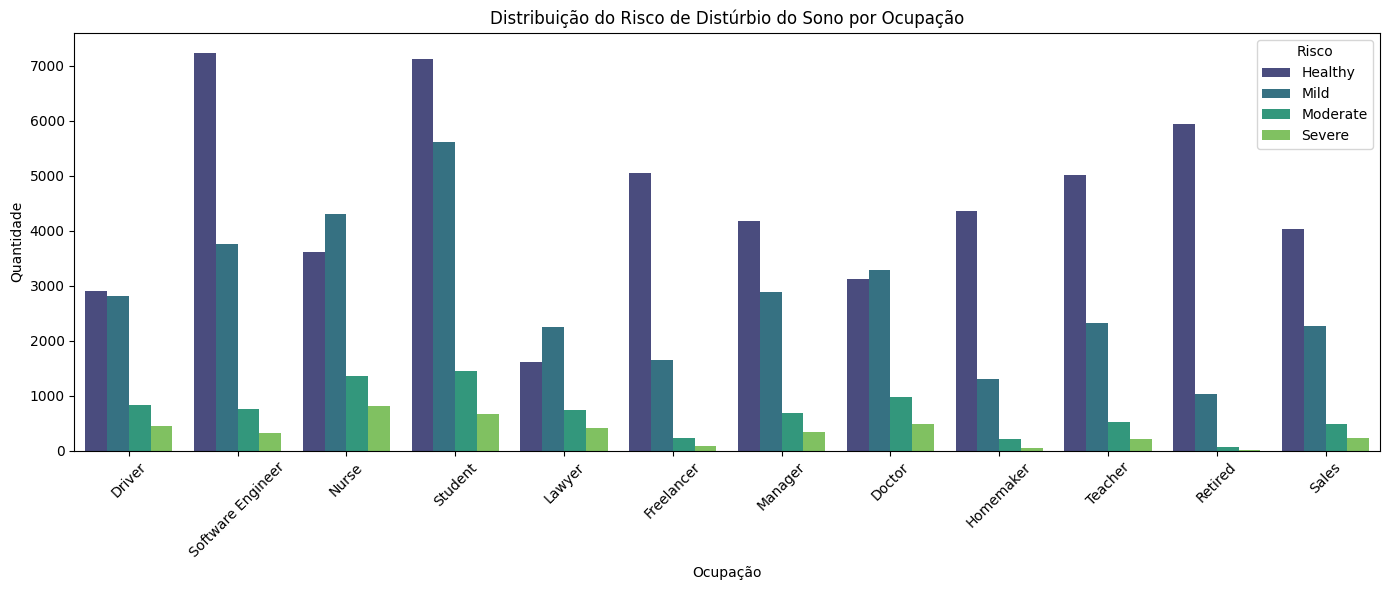

In [11]:
plt.figure(figsize=(14, 6))
sns.countplot(data=df, x='occupation',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Ocupação')
plt.xlabel('Ocupação')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

###Interpretação - Distribuição por ocupação

O padrão se repete, as ocupações com mais registros:

(Software Engineer, Student, Teacher);

Acabam dominando em todas as categorias. Mas um detalhe interessante, (Doctor) é a única ocupação onde Mild quase empata com Healthy, isso pode indicar que médicos têm um padrão de sono mais comprometido proporcionalmente.

###6-Distribuição do risco de distúrbio de sono por Horas Trabalhadas:

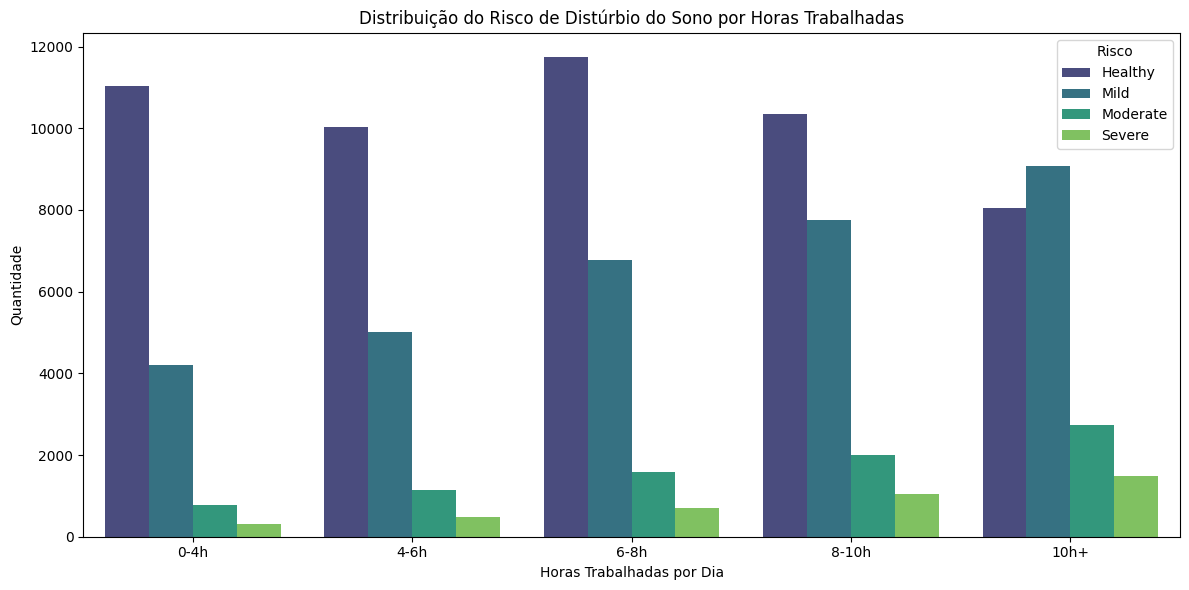

In [12]:
df['faixa_horas'] = pd.cut(df['work_hours_that_day'],
                            bins=[0, 4, 6, 8, 10, 24],
                            labels=['0-4h', '4-6h', '6-8h', '8-10h', '10h+'])

plt.figure(figsize=(12, 6))
sns.countplot(data=df, x='faixa_horas',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Horas Trabalhadas')
plt.xlabel('Horas Trabalhadas por Dia')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Horas Trabalhadas por Dia

Pessoas que trabalham mais horas por dia (8-10h e 10h+) apresentam
proporcionalmente mais casos Moderate e Severe em relação às que trabalham menos.

Isso reforça a relação entre carga de trabalho elevada e maior risco
de distúrbio do sono.

###7-Distribuição do risco de distúrbio de sono por Exercício Diário:

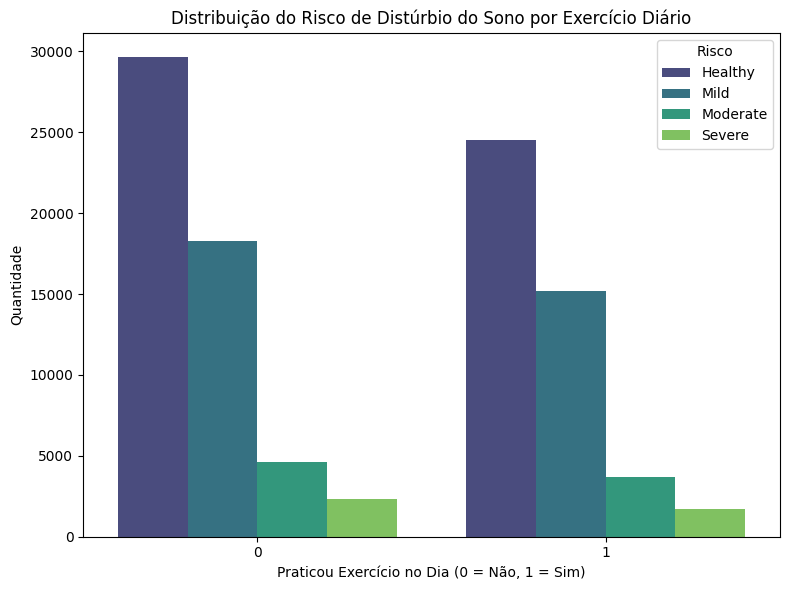

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x='exercise_day',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Exercício Diário')
plt.xlabel('Praticou Exercício no Dia (0 = Não, 1 = Sim)')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Exercício Diário

A variável exercise_day é binária: indica se a pessoa praticou
exercício naquele dia (1) ou não (0).

Proporcionalmente, pessoas que não se exercitaram (0) concentram
mais casos Moderate e Severe, enquanto quem se exercitou (1)
tem mais casos Healthy — reforçando que a prática de exercício
está associada a um menor risco de distúrbio do sono.

###8-Distribuição do risco de distúrbio de sono por Condição Mental:

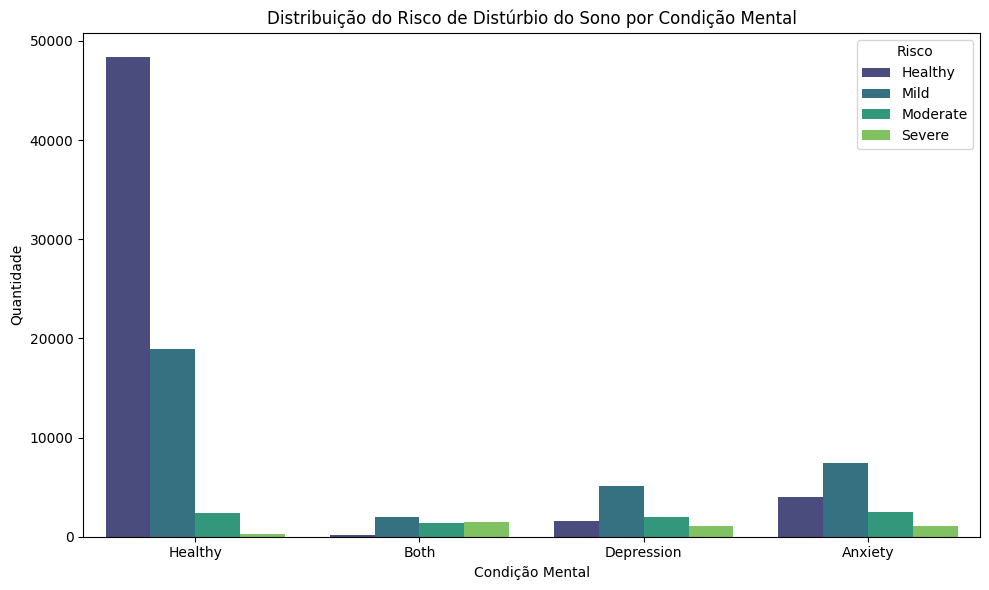

In [14]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='mental_health_condition',
              hue='sleep_disorder_risk',
              hue_order=['Healthy', 'Mild', 'Moderate', 'Severe'],
              palette='viridis')
plt.title('Distribuição do Risco de Distúrbio do Sono por Condição Mental')
plt.xlabel('Condição Mental')
plt.ylabel('Quantidade')
plt.legend(title='Risco')
plt.tight_layout()
plt.show()

### Interpretação — Condição Mental

As 4 categorias representam: sem condição (Healthy), apenas Ansiedade,
apenas Depressão, e ambas simultaneamente (Both).

Pessoas com Ansiedade, Depressão ou ambas apresentam proporcionalmente
muito mais casos Moderate e Severe em comparação com pessoas sem
condição mental diagnosticada.

O grupo Both (ambas as condições) tende a concentrar os casos mais graves,
reforçando que mental_health_condition é uma das variáveis com maior
poder preditivo para o modelo.

###9-Distribuição do nível de estresse por risco de distúrbio de sono:


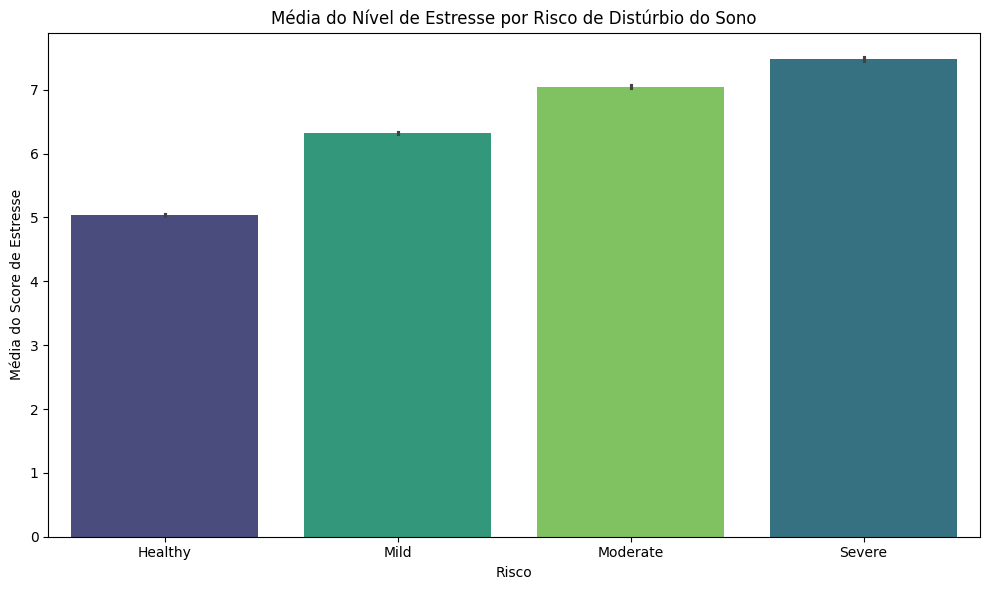

In [15]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='stress_score',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média do Nível de Estresse por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média do Score de Estresse')
plt.tight_layout()
plt.show()

### Interpretação — Nível de Estresse por Risco

O gráfico mostra a média do score de estresse para cada categoria de risco,
evidenciando uma progressão clara e consistente:

- Healthy: média ~5.0
- Mild: média ~6.4
- Moderate: média ~7.0
- Severe: média ~7.5

Quanto maior o risco de distúrbio do sono, maior o nível médio de estresse.
Essa relação direta sugere que stress_score é uma das variáveis com maior
poder preditivo para o modelo.

###10-Distribuição da duração do sono por risco de distúrbio de sono:

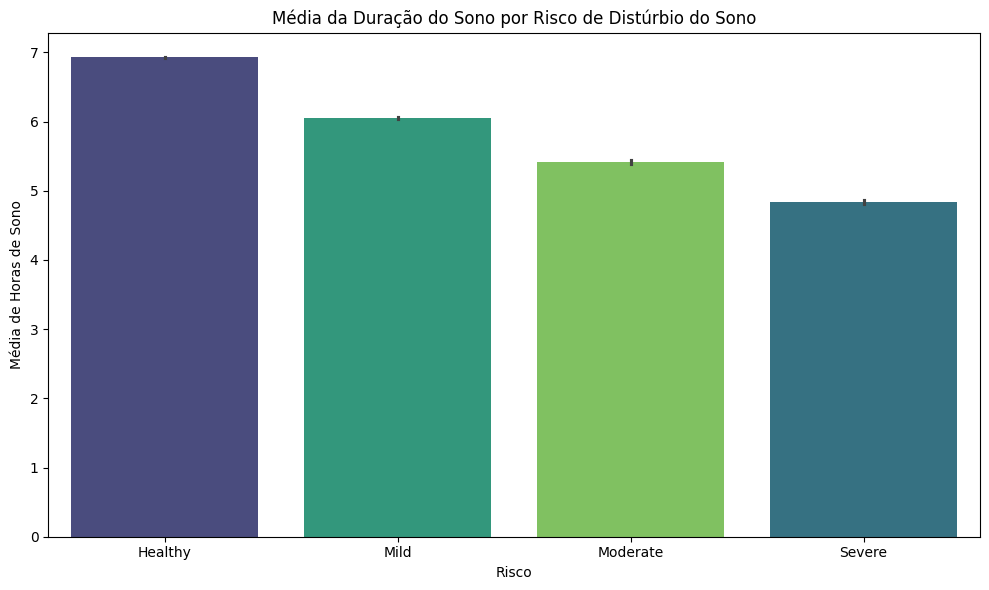

In [16]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='sleep_duration_hrs',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média da Duração do Sono por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média de Horas de Sono')
plt.tight_layout()
plt.show()

### Interpretação — Duração do Sono por Risco

O gráfico mostra a média de horas de sono por categoria de risco,
revelando uma queda progressiva conforme o risco aumenta:

- Healthy: média ~7.0 horas
- Mild: média ~6.1 horas
- Moderate: média ~5.4 horas
- Severe: média ~4.9 horas

Pessoas com risco Severe dormem em média 2 horas a menos que pessoas
Healthy. Essa relação forte confirma que sleep_duration_hrs será uma
das features mais importantes para o modelo de classificação.

###11- Distribuição da qualidade do Sono por Risco

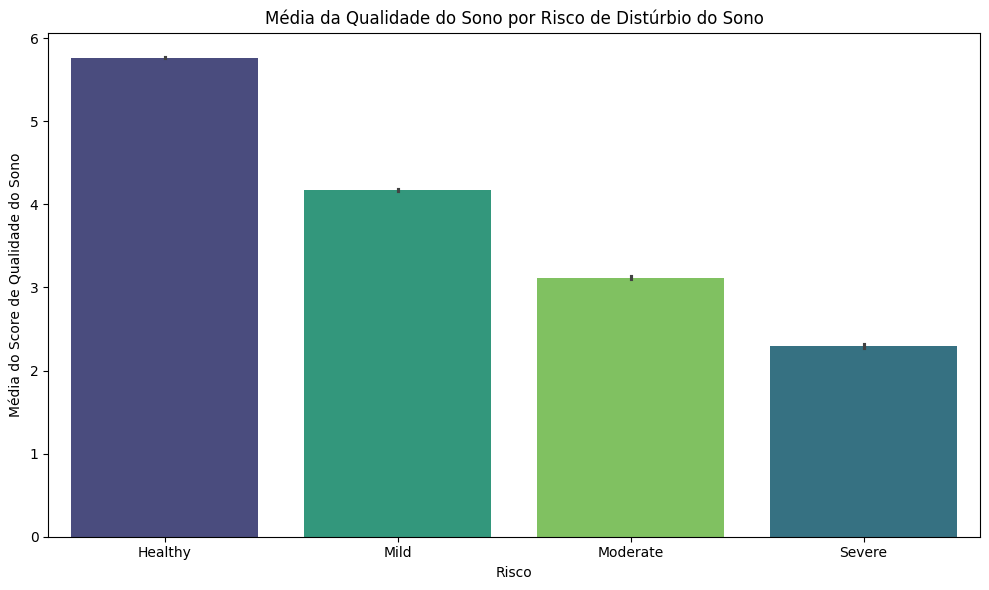

In [17]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='sleep_quality_score',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média da Qualidade do Sono por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média do Score de Qualidade do Sono')
plt.tight_layout()
plt.show()

### Interpretação — Qualidade do Sono por Risco

O gráfico mostra a média do score de qualidade do sono para cada
categoria de risco, evidenciando uma queda progressiva muito clara:

- Healthy: média ~5.8
- Mild: média ~4.2
- Moderate: média ~3.1
- Severe: média ~2.3

A queda é drástica — pessoas com risco Severe dormem com qualidade
menos da metade das pessoas Healthy. Isso confirma que
sleep_quality_score é uma das variáveis com maior poder preditivo
para o modelo, apresentando a relação mais clara entre todas as
variáveis analisadas.

###12-Distribuição da Cafeína Antes de Dormir por Risco

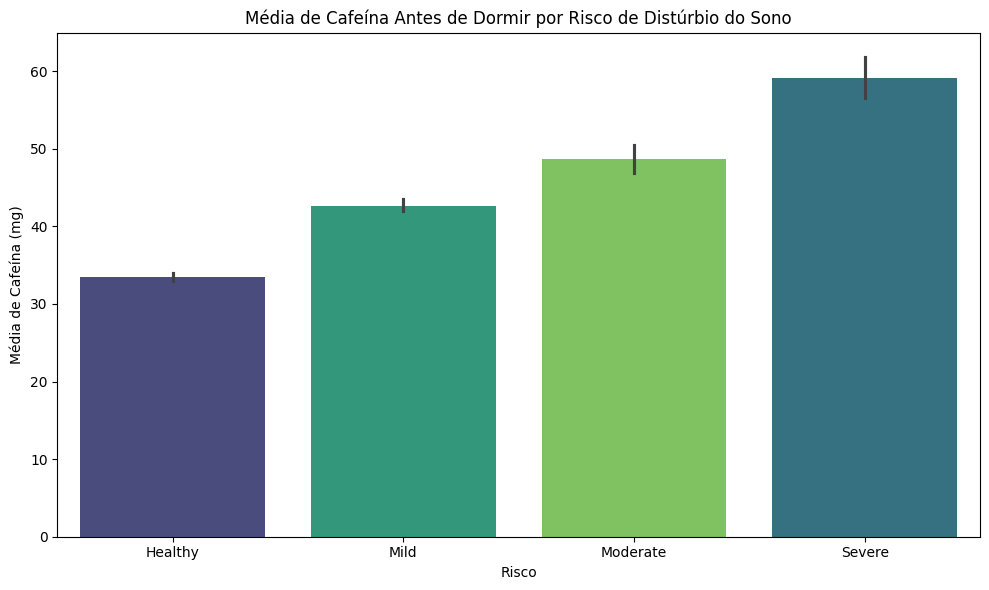

In [18]:
plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='sleep_disorder_risk',
            y='caffeine_mg_before_bed',
            order=['Healthy', 'Mild', 'Moderate', 'Severe'],
            hue='sleep_disorder_risk',
            palette='viridis',
            legend=False)
plt.title('Média de Cafeína Antes de Dormir por Risco de Distúrbio do Sono')
plt.xlabel('Risco')
plt.ylabel('Média de Cafeína (mg)')
plt.tight_layout()
plt.show()

### Interpretação — Cafeína Antes de Dormir por Risco

O gráfico mostra a média de miligramas de cafeína consumida antes
de dormir para cada categoria de risco:

- Healthy: média ~34mg
- Mild: média ~43mg
- Moderate: média ~49mg
- Severe: média ~59mg

Há uma progressão consistente — pessoas com risco Severe consomem
quase o dobro de cafeína antes de dormir em comparação com pessoas
Healthy. Isso reforça que o consumo de cafeína próximo ao horário
de dormir é um fator de risco relevante para distúrbios do sono.

## Pré-processamento

In [19]:
# Removendo colunas irrelevantes
df = df.drop(columns=['person_id', 'country'])

print('Colunas restantes:', df.shape[1])
print(df.columns.tolist())

Colunas restantes: 32
['age', 'gender', 'occupation', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested', 'faixa_etaria', 'faixa_horas']


### Conversão de variáveis categóricas:

In [20]:
from sklearn.preprocessing import LabelEncoder #ferramenta que converte texto em número

le = LabelEncoder() #cria um objeto LabelEncoder que vamos usar para fazer as conversões.

colunas_categoricas = ['gender', 'occupation', 'chronotype',
                       'mental_health_condition', 'season', 'day_type']

for col in colunas_categoricas: #Loop que passa por cada coluna da lista e aplica a conversão.
    df[col] = le.fit_transform(df[col])
#O fit_transform faz duas coisas ao mesmo tempo: aprende quais são os valores únicos da coluna (fit) e já converte para número (transform).
#Por exemplo, gender vira: Female=0, Male=1, Other=2.

# Convertendo a variável alvo
df['sleep_disorder_risk'] = le.fit_transform(df['sleep_disorder_risk'])

print('Mapeamento da variável alvo:')
print(dict(zip(le.classes_, le.transform(le.classes_))))
print()
print(df.head())

Mapeamento da variável alvo:
{'Healthy': np.int64(0), 'Mild': np.int64(1), 'Moderate': np.int64(2), 'Severe': np.int64(3)}

   age  gender  occupation   bmi  sleep_duration_hrs  sleep_quality_score  \
0   29       0           1  25.7                6.19                  6.6   
1   55       0           9  22.0                8.32                  6.9   
2   42       1           6  25.0                3.74                  1.0   
3   37       0          10  29.5                6.79                  6.4   
4   23       1           4  23.6                5.02                  3.2   

   rem_percentage  deep_sleep_percentage  sleep_latency_mins  \
0            22.5                   19.3                  16   
1            26.9                   14.9                  17   
2            20.2                   16.2                  26   
3            17.7                   17.7                  13   
4            23.3                   18.3                  30   

   wake_episodes_per_night  

In [21]:
# Remove apenas as colunas de faixa que foram criadas para visualização
colunas_para_remover = ['faixa_etaria', 'faixa_horas']
colunas_existentes = [col for col in colunas_para_remover if col in df.columns]
df = df.drop(columns=colunas_existentes)

print('Colunas restantes:', df.shape[1])
print(df.columns.tolist())

Colunas restantes: 30
['age', 'gender', 'occupation', 'bmi', 'sleep_duration_hrs', 'sleep_quality_score', 'rem_percentage', 'deep_sleep_percentage', 'sleep_latency_mins', 'wake_episodes_per_night', 'caffeine_mg_before_bed', 'alcohol_units_before_bed', 'screen_time_before_bed_mins', 'exercise_day', 'steps_that_day', 'nap_duration_mins', 'stress_score', 'work_hours_that_day', 'chronotype', 'mental_health_condition', 'heart_rate_resting_bpm', 'sleep_aid_used', 'shift_work', 'room_temperature_celsius', 'weekend_sleep_diff_hrs', 'season', 'day_type', 'cognitive_performance_score', 'sleep_disorder_risk', 'felt_rested']


### Separando features e variável alvo:

In [22]:
from sklearn.model_selection import train_test_split

# X = todas as colunas exceto a variável alvo
# y = apenas a variável alvo
X = df.drop(columns=['sleep_disorder_risk']) #Cria o X com todas as 29 colunas, exceto a variável alvo — são as features que o modelo vai usar para aprender.
y = df['sleep_disorder_risk'] #Cria o y com apenas a variável alvo — é o que queremos que o modelo aprenda a prever.

# Dividindo em 80% treino e 20% teste
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y) #Divide os dados em 80% treino e 20% teste:

print('Tamanho do treino:', X_train.shape)
print('Tamanho do teste:', X_test.shape)
print()
print('Distribuição das classes no treino:')
print(y_train.value_counts(normalize=True) * 100)

Tamanho do treino: (80000, 29)
Tamanho do teste: (20000, 29)

Distribuição das classes no treino:
sleep_disorder_risk
0    54.15625
1    33.47875
2     8.29875
3     4.06625
Name: proportion, dtype: float64


### Comparação de Algoritmos de Classificação:

In [23]:
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score
import time
import warnings
warnings.filterwarnings('ignore')

# class_weight='balanced' faz o modelo penalizar mais os erros nas classes
# minoritárias (Moderate e Severe), corrigindo o viés do desbalanceamento.
modelos = {
    'Decision Tree':       DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    'Random Forest':       RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'Extra Trees':         ExtraTreesClassifier(n_estimators=100, random_state=42, class_weight='balanced'),
    'KNN':                 KNeighborsClassifier(),
    'Naive Bayes':         GaussianNB(),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
}

# F1-Macro é a métrica principal: trata todas as classes igualmente,
# sem ser enganado pelo domínio da classe Healthy (54% dos dados).
print('=== SEM SMOTE ===')
print(f'{"Modelo":<25} {"Acurácia":>10} {"F1-Macro":>10} {"Tempo":>10}')
print('-' * 57)

resultados_sem_smote = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)
    tempo = time.time() - inicio
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    resultados_sem_smote[nome] = {'accuracy': acc, 'f1_macro': f1}
    print(f'{nome:<25} {acc*100:>9.2f}% {f1*100:>9.2f}% {tempo:>9.1f}s')


=== SEM SMOTE ===
Modelo                      Acurácia   F1-Macro      Tempo
---------------------------------------------------------
Decision Tree                 88.78%     76.48%       2.2s
Random Forest                 89.53%     78.23%      27.4s
Extra Trees                   83.80%     69.95%      18.3s
KNN                           61.60%     36.45%      11.4s
Naive Bayes                   71.84%     61.21%       0.1s
Logistic Regression           69.03%     59.35%      71.3s


In [24]:
from imblearn.over_sampling import SMOTE

print('Distribuição ANTES do SMOTE:')
print(y_train.value_counts())

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print('\nDistribuição DEPOIS do SMOTE:')
print(y_train_smote.value_counts())

Distribuição ANTES do SMOTE:
sleep_disorder_risk
0    43325
1    26783
2     6639
3     3253
Name: count, dtype: int64

Distribuição DEPOIS do SMOTE:
sleep_disorder_risk
0    43325
1    43325
2    43325
3    43325
Name: count, dtype: int64


In [25]:
print('=== COM SMOTE ===')
print(f'{"Modelo":<25} {"Acurácia":>10} {"F1-Macro":>10} {"Tempo":>10}')
print('-' * 57)

resultados_com_smote = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_train_smote, y_train_smote)
    y_pred = modelo.predict(X_test)
    tempo = time.time() - inicio
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')
    resultados_com_smote[nome] = {'accuracy': acc, 'f1_macro': f1}
    print(f'{nome:<25} {acc*100:>9.2f}% {f1*100:>9.2f}% {tempo:>9.1f}s')

=== COM SMOTE ===
Modelo                      Acurácia   F1-Macro      Tempo
---------------------------------------------------------
Decision Tree                 84.88%     70.68%       7.3s
Random Forest                 87.33%     76.80%      94.0s
Extra Trees                   82.37%     71.01%      40.6s
KNN                           55.48%     42.22%      22.2s
Naive Bayes                   67.78%     57.47%       0.1s
Logistic Regression           69.65%     59.00%     135.1s


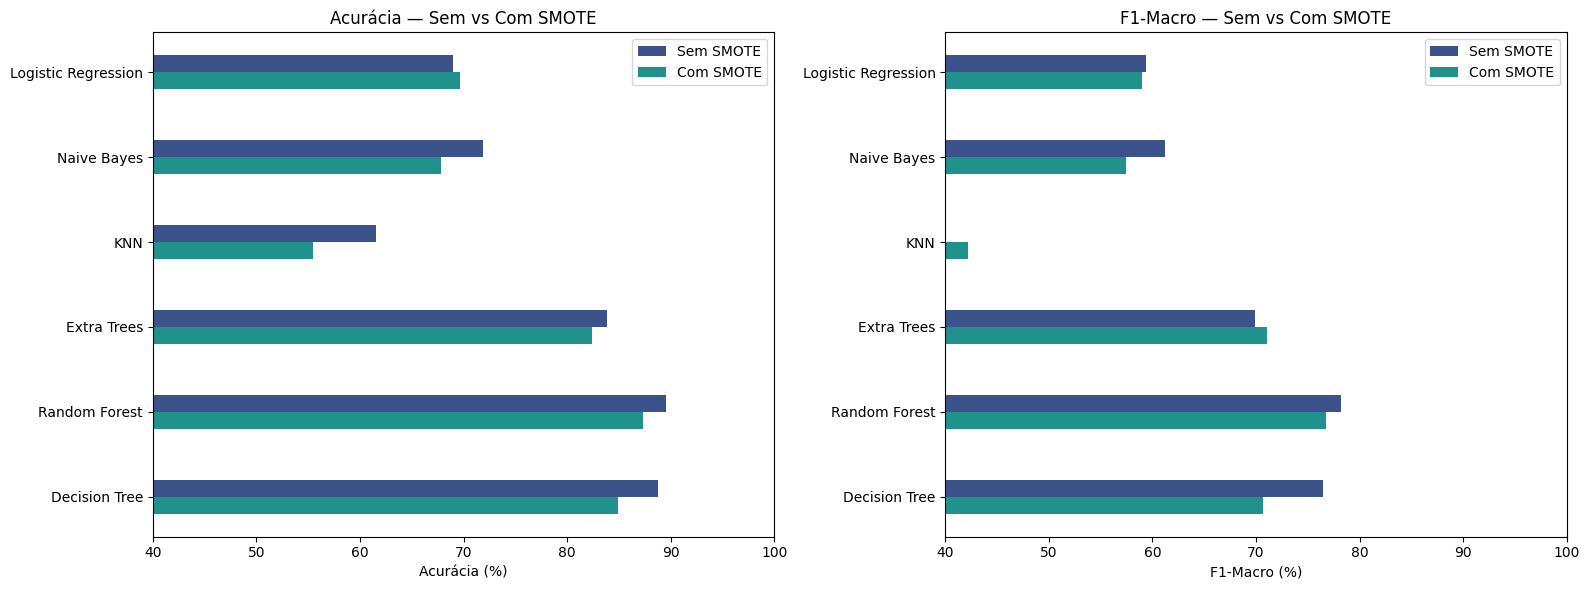

In [26]:
modelos_nomes = list(resultados_sem_smote.keys())

acc_sem = [resultados_sem_smote[m]['accuracy']*100 for m in modelos_nomes]
acc_com = [resultados_com_smote[m]['accuracy']*100 for m in modelos_nomes]
f1_sem = [resultados_sem_smote[m]['f1_macro']*100 for m in modelos_nomes]
f1_com = [resultados_com_smote[m]['f1_macro']*100 for m in modelos_nomes]

x = np.arange(len(modelos_nomes))
width = 0.2

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico de Acurácia
axes[0].barh(x + width/2, acc_sem, width, label='Sem SMOTE', color='#3b528b')
axes[0].barh(x - width/2, acc_com, width, label='Com SMOTE', color='#21918c')
axes[0].set_title('Acurácia — Sem vs Com SMOTE')
axes[0].set_xlabel('Acurácia (%)')
axes[0].set_yticks(x)
axes[0].set_yticklabels(modelos_nomes)
axes[0].set_xlim(40, 100)
axes[0].legend()

# Gráfico de F1-Macro
axes[1].barh(x + width/2, f1_sem, width, label='Sem SMOTE', color='#3b528b')
axes[1].barh(x - width/2, f1_com, width, label='Com SMOTE', color='#21918c')
axes[1].set_title('F1-Macro — Sem vs Com SMOTE')
axes[1].set_xlabel('F1-Macro (%)')
axes[1].set_yticks(x)
axes[1].set_yticklabels(modelos_nomes)
axes[1].set_xlim(40, 100)
axes[1].legend()

plt.tight_layout()
plt.show()

### Interpretação — Impacto do SMOTE

O SMOTE equilibrou completamente as classes no treino (43.325 amostras por classe),
mas os resultados mostram que isso **piorou o desempenho** em todos os modelos:

| Modelo | Acurácia sem SMOTE | F1-Macro sem SMOTE | Acurácia com SMOTE | F1-Macro com SMOTE |
|---|---|---|---|---|
| Decision Tree | 88,78% | 76,48% | 84,88% | 70,68% |
| Random Forest | 89,53% | 78,23% | 87,33% | 76,80% |
| Extra Trees | 83,80% | 69,95% | 82,37% | 71,01% |
| KNN | 61,60% | 36,45% | 55,48% | 42,22% |
| Naive Bayes | 71,84% | 61,21% | 67,78% | 57,47% |
| Logistic Regression | 69,03% | 59,35% | 69,65% | 59,00% |

O oversampling sintético gerou instâncias artificiais de Moderate e Severe que não
refletem bem o padrão real dos dados, prejudicando a generalização. A abordagem de
`class_weight='balanced'` — que ajusta os pesos internamente sem criar dados sintéticos —
se mostrou mais eficaz. **Por isso, os experimentos seguintes não utilizam SMOTE.**


## Avaliação dos Modelos Base:

========== Decision Tree ==========
Acurácia : 88.78%
F1-Macro : 76.48%  ← métrica principal (trata classes igualmente)

              precision    recall  f1-score   support

     Healthy       0.97      0.97      0.97     10831
        Mild       0.86      0.87      0.87      6696
    Moderate       0.55      0.54      0.54      1660
      Severe       0.69      0.67      0.68       813

    accuracy                           0.89     20000
   macro avg       0.77      0.76      0.76     20000
weighted avg       0.89      0.89      0.89     20000



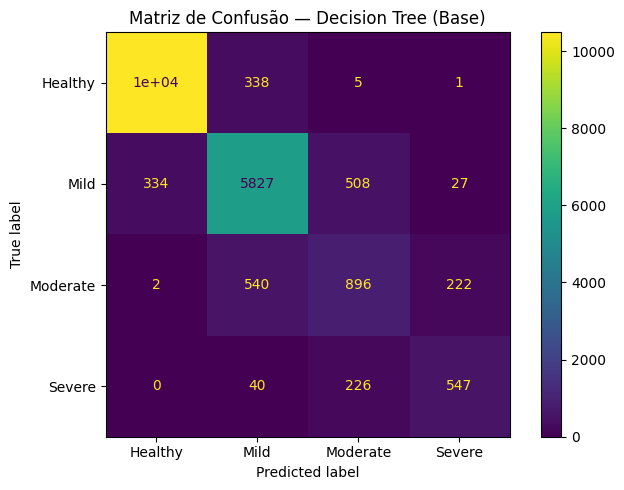


========== Random Forest ==========
Acurácia : 89.53%
F1-Macro : 78.23%  ← métrica principal (trata classes igualmente)

              precision    recall  f1-score   support

     Healthy       0.96      0.97      0.96     10831
        Mild       0.84      0.91      0.87      6696
    Moderate       0.66      0.46      0.54      1660
      Severe       0.83      0.68      0.75       813

    accuracy                           0.90     20000
   macro avg       0.82      0.75      0.78     20000
weighted avg       0.89      0.90      0.89     20000



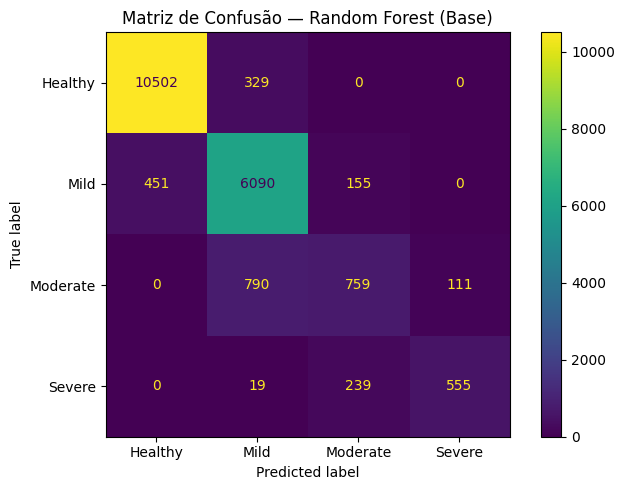

In [27]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

nomes = ['Decision Tree', 'Random Forest']
modelos_escolhidos = [
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
]

resultados_base = {}

for nome, modelo in zip(nomes, modelos_escolhidos):
    modelo.fit(X_train, y_train)
    y_pred = modelo.predict(X_test)

    acc  = accuracy_score(y_test, y_pred)
    f1m  = f1_score(y_test, y_pred, average='macro')
    resultados_base[nome] = {'acc': acc, 'f1_macro': f1m, 'model': modelo}

    print(f'========== {nome} ==========')
    print(f'Acurácia : {acc*100:.2f}%')
    print(f'F1-Macro : {f1m*100:.2f}%  ← métrica principal (trata classes igualmente)')
    print()
    print(classification_report(y_test, y_pred,
          target_names=['Healthy', 'Mild', 'Moderate', 'Severe']))

    fig, ax = plt.subplots(figsize=(7, 5))
    ConfusionMatrixDisplay.from_predictions(
        y_test, y_pred,
        display_labels=['Healthy', 'Mild', 'Moderate', 'Severe'],
        cmap='viridis', ax=ax)
    ax.set_title(f'Matriz de Confusão — {nome} (Base)')
    plt.tight_layout()
    plt.show()
    print()


### Interpretação — Avaliação dos Modelos Base

#### O que é a Matriz de Confusão?
A matriz de confusão mostra onde o modelo acerta e onde erra: as linhas representam
os valores reais e as colunas os valores preditos. A diagonal principal (de cima à
esquerda para baixo à direita) mostra os acertos; os demais valores são erros.

#### Decision Tree — Base
- **Acurácia: 88,78% | F1-Macro: 76,48%**
- Healthy: precisão 0,97 / recall 0,97 — classe bem detectada, é a maioria dos dados
- Mild: precisão 0,86 / recall 0,87 — bom desempenho
- Moderate: precisão 0,55 / recall 0,54 — desempenho fraco, modelo confunde com Mild
- Severe: precisão 0,69 / recall 0,67 — resultado moderado para a classe mais crítica

#### Random Forest — Base
- **Acurácia: 89,53% | F1-Macro: 78,23%**
- Healthy: precisão 0,96 / recall 0,97 — excelente
- Mild: precisão 0,84 / recall 0,91 — recall alto, poucos Mild passam despercebidos
- Moderate: precisão 0,66 / recall 0,46 — recall baixo, muitos Moderate não detectados
- Severe: precisão 0,83 / recall 0,68 — boa precisão, recall ainda pode melhorar

#### Por que a acurácia é alta mas o F1-Macro é menor?
O dataset tem 54% de casos Healthy. Um modelo que acertasse apenas os Healthy já
teria ~54% de acurácia sem aprender nada útil. O F1-Macro trata todas as classes
igualmente — por isso é a métrica principal aqui: revela que Moderate e Severe
ainda são os maiores desafios para ambos os modelos, independentemente da acurácia alta.


## Otimização de Hiperparâmetros — Pipeline em Cascata

Nesta seção, as três técnicas de otimização trabalham de forma **sequencial e colaborativa**,
onde cada etapa alimenta e refina a seguinte:

```
Bayesian Search  →  Randomized Search  →  Grid Search
(espaço amplo)       (região refinada)      (grade precisa)
```

- **Bayesian Search**: Explora um espaço amplo de hiperparâmetros de forma inteligente,
  aprendendo quais regiões são mais promissoras a cada iteração.
- **Randomized Search**: Recebe os melhores parâmetros do Bayesian e realiza uma busca
  aleatória em uma região estreitada ao redor desses valores.
- **Grid Search**: Recebe os melhores parâmetros do Randomized e executa busca exaustiva
  em uma grade pequena e precisa, finalizando o ajuste fino.

**Métrica usada em toda otimização: F1-Macro** — escolhida por tratar todas as classes
igualmente, evitando que o desbalanceamento inflacione artificialmente o resultado.


### Etapa 1/3 — Bayesian Search (Decision Tree)
Explora o espaço amplo de hiperparâmetros de forma inteligente.
Cada iteração usa os resultados anteriores para decidir onde buscar a seguir.
O espaço aqui é propositalmente largo — queremos encontrar a **região promissora**,
não o ponto exato.

In [28]:
import time
!pip install scikit-optimize -q
from skopt import BayesSearchCV
from skopt.space import Integer, Categorical

# ── ETAPA 1: Bayesian Search — espaço amplo ──────────────────────────────────
param_bayes_dt = {
    'max_depth':         Integer(3, 50),
    'min_samples_split': Integer(2, 20),
    'min_samples_leaf':  Integer(1, 10),
    'criterion':         Categorical(['gini', 'entropy'])
}

print('Rodando Bayesian Search — Decision Tree (espaço amplo)...')
inicio_bayes_dt = time.time()

bayes_dt = BayesSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_bayes_dt,
    n_iter=30,
    cv=3,
    scoring='f1_macro',   # métrica principal — não se deixa enganar pelo desbalanceamento
    random_state=42,
    n_jobs=-1,
    verbose=0
)
bayes_dt.fit(X_train, y_train)
tempo_bayes_dt = time.time() - inicio_bayes_dt

y_pred_bayes_dt = bayes_dt.best_estimator_.predict(X_test)
acc_bayes_dt  = accuracy_score(y_test, y_pred_bayes_dt)
f1_bayes_dt   = f1_score(y_test, y_pred_bayes_dt, average='macro')

print(f'Tempo           : {tempo_bayes_dt:.1f}s')
print(f'Melhores params : {dict(bayes_dt.best_params_)}')
print(f'F1-Macro (cv)   : {bayes_dt.best_score_*100:.2f}%')
print(f'Acurácia (teste): {acc_bayes_dt*100:.2f}%')
print(f'F1-Macro (teste): {f1_bayes_dt*100:.2f}%')
print()
print('→ Passando melhores parâmetros para o Randomized Search...')


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 8.7 MB/s eta 0:00:00
Rodando Bayesian Search — Decision Tree (espaço amplo)...
Tempo           : 127.6s
Melhores params : {'criterion': 'entropy', 'max_depth': 13, 'min_samples_leaf': 1, 'min_samples_split': 2}
F1-Macro (cv)   : 76.36%
Acurácia (teste): 88.66%
F1-Macro (teste): 77.84%

→ Passando melhores parâmetros para o Randomized Search...


### Etapa 2/3 — Randomized Search (Decision Tree)
Recebe os melhores parâmetros do Bayesian e **estreita o espaço de busca** ao redor
desses valores. Em vez de explorar todo o universo de possibilidades, o Randomized
sorteia combinações aleatórias dentro dessa região mais promissora.

In [29]:
from sklearn.model_selection import RandomizedSearchCV

# ── ETAPA 2: Randomized Search — região estreitada em torno do Bayesian ───────
bp = bayes_dt.best_params_
md  = int(bp['max_depth'])
mss = int(bp['min_samples_split'])
msl = int(bp['min_samples_leaf'])
crit = bp['criterion']

# Cria um intervalo de ±5 em torno do melhor max_depth, ±4 nos outros
param_dist_dt = {
    'max_depth':         list(range(max(3, md - 5),  md + 6)),
    'min_samples_split': list(range(max(2, mss - 4), mss + 5)),
    'min_samples_leaf':  list(range(max(1, msl - 3), msl + 4)),
    'criterion':         ['gini', 'entropy']
}

print(f'Espaço Randomized (baseado no Bayesian: depth={md}, split={mss}, leaf={msl}):')
print(f'  max_depth:         {param_dist_dt["max_depth"]}')
print(f'  min_samples_split: {param_dist_dt["min_samples_split"]}')
print(f'  min_samples_leaf:  {param_dist_dt["min_samples_leaf"]}')
print()
print('Rodando Randomized Search — Decision Tree (região refinada)...')
inicio_random_dt = time.time()

random_dt = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_dist_dt,
    n_iter=30,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
random_dt.fit(X_train, y_train)
tempo_random_dt = time.time() - inicio_random_dt

y_pred_random_dt = random_dt.best_estimator_.predict(X_test)
acc_random_dt  = accuracy_score(y_test, y_pred_random_dt)
f1_random_dt   = f1_score(y_test, y_pred_random_dt, average='macro')

print(f'Tempo           : {tempo_random_dt:.1f}s')
print(f'Melhores params : {random_dt.best_params_}')
print(f'F1-Macro (cv)   : {random_dt.best_score_*100:.2f}%')
print(f'Acurácia (teste): {acc_random_dt*100:.2f}%')
print(f'F1-Macro (teste): {f1_random_dt*100:.2f}%')
print()
print('→ Passando melhores parâmetros para o Grid Search...')


Espaço Randomized (baseado no Bayesian: depth=13, split=2, leaf=1):
  max_depth:         [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18]
  min_samples_split: [2, 3, 4, 5, 6]
  min_samples_leaf:  [1, 2, 3, 4]

Rodando Randomized Search — Decision Tree (região refinada)...
Tempo           : 98.3s
Melhores params : {'min_samples_split': 4, 'min_samples_leaf': 1, 'max_depth': 14, 'criterion': 'entropy'}
F1-Macro (cv)   : 76.59%
Acurácia (teste): 89.01%
F1-Macro (teste): 77.92%

→ Passando melhores parâmetros para o Grid Search...


### Etapa 3/3 — Grid Search (Decision Tree)
Recebe os melhores parâmetros do Randomized e realiza uma **busca exaustiva em grade
pequena e precisa** ao redor desse ponto. Como o espaço já foi muito reduzido pelas
etapas anteriores, o Grid Search consegue testar todas as combinações sem custo alto.

In [30]:
from sklearn.model_selection import GridSearchCV

# ── ETAPA 3: Grid Search — grade precisa ao redor do Randomized ───────────────
rp = random_dt.best_params_
md2  = int(rp['max_depth'])
mss2 = int(rp['min_samples_split'])
msl2 = int(rp['min_samples_leaf'])

param_grid_dt = {
    'max_depth':         sorted(set([max(3, md2 - 2), md2, md2 + 2])),
    'min_samples_split': sorted(set([max(2, mss2 - 1), mss2, mss2 + 1])),
    'min_samples_leaf':  sorted(set([max(1, msl2 - 1), msl2, msl2 + 1])),
    'criterion':         [rp['criterion']]
}

n_combos = 1
for v in param_grid_dt.values():
    n_combos *= len(v)

print(f'Grade Grid Search (baseada no Randomized: depth={md2}, split={mss2}, leaf={msl2}):')
print(f'  max_depth:         {param_grid_dt["max_depth"]}')
print(f'  min_samples_split: {param_grid_dt["min_samples_split"]}')
print(f'  min_samples_leaf:  {param_grid_dt["min_samples_leaf"]}')
print(f'  criterion:         {param_grid_dt["criterion"]}')
print(f'  Total combinações: {n_combos}')
print()
print('Rodando Grid Search — Decision Tree (ajuste fino)...')
inicio_grid_dt = time.time()

grid_dt = GridSearchCV(
    DecisionTreeClassifier(random_state=42, class_weight='balanced'),
    param_grid_dt,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
grid_dt.fit(X_train, y_train)
tempo_grid_dt = time.time() - inicio_grid_dt

y_pred_grid_dt = grid_dt.best_estimator_.predict(X_test)
acc_grid_dt  = accuracy_score(y_test, y_pred_grid_dt)
f1_grid_dt   = f1_score(y_test, y_pred_grid_dt, average='macro')

print(f'Tempo           : {tempo_grid_dt:.1f}s')
print(f'Melhores params : {grid_dt.best_params_}')
print(f'F1-Macro (cv)   : {grid_dt.best_score_*100:.2f}%')
print(f'Acurácia (teste): {acc_grid_dt*100:.2f}%')
print(f'F1-Macro (teste): {f1_grid_dt*100:.2f}%')


Grade Grid Search (baseada no Randomized: depth=14, split=4, leaf=1):
  max_depth:         [12, 14, 16]
  min_samples_split: [3, 4, 5]
  min_samples_leaf:  [1, 2]
  criterion:         ['entropy']
  Total combinações: 18

Rodando Grid Search — Decision Tree (ajuste fino)...
Tempo           : 71.6s
Melhores params : {'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 4}
F1-Macro (cv)   : 76.59%
Acurácia (teste): 89.01%
F1-Macro (teste): 77.92%


### Resumo — Pipeline Cascata (Decision Tree)

| Etapa | F1-Macro | Acurácia | Tempo |
|---|---|---|---|
| Base (class_weight) | 76,48% | 88,78% | — |
| 1. Bayesian Search | 77,84% | 88,66% | 127,6s |
| 2. Randomized Search | 77,92% | 89,01% | 98,3s |
| 3. Grid Search | 77,92% | 89,01% | 71,6s |

**Parâmetros finais:** `criterion=entropy`, `max_depth=14`, `min_samples_leaf=1`, `min_samples_split=4`

O pipeline cascata funcionou como planejado: o Bayesian encontrou a região promissora
(`max_depth` em torno de 13), o Randomized refinou para `depth=14, split=4` e o Grid
confirmou esse ponto com busca exaustiva. O ganho total foi de **+1,44 p.p. de F1-Macro**
sobre o modelo base, passando de 76,48% para 77,92%. O tempo decrescente por etapa
(127s → 98s → 71s) também ilustra a eficiência do pipeline: cada etapa trabalha com
um espaço progressivamente menor.


===== Decision Tree — Pipeline Cascata =====
Etapa                    F1-Macro   Acurácia      Tempo
--------------------------------------------------------
Base (class_weight)        76.48%     88.78%          —
1. Bayesian Search         77.84%     88.66%     127.6s
2. Randomized Search       77.92%     89.01%      98.3s
3. Grid Search             77.92%     89.01%      71.6s

Parâmetros finais (Grid Search): {'criterion': 'entropy', 'max_depth': 14, 'min_samples_leaf': 1, 'min_samples_split': 4}


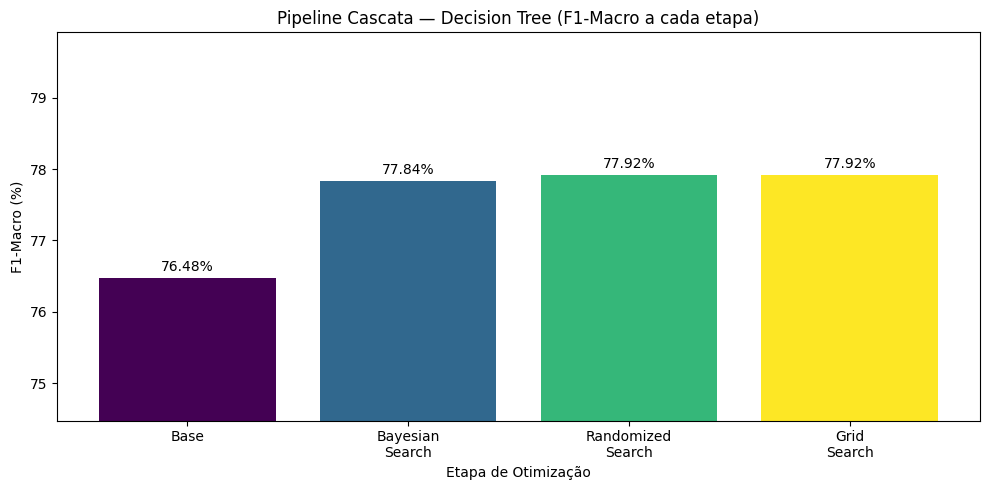

In [31]:
# Consolidando resultados do pipeline cascata — Decision Tree
f1_base_dt = resultados_base['Decision Tree']['f1_macro']

print('===== Decision Tree — Pipeline Cascata =====')
print(f'{"Etapa":<22} {"F1-Macro":>10} {"Acurácia":>10} {"Tempo":>10}')
print('-' * 56)
print(f'{"Base (class_weight)":<22} {f1_base_dt*100:>9.2f}% {resultados_base["Decision Tree"]["acc"]*100:>9.2f}% {"—":>10}')
print(f'{"1. Bayesian Search":<22} {f1_bayes_dt*100:>9.2f}% {acc_bayes_dt*100:>9.2f}% {tempo_bayes_dt:>9.1f}s')
print(f'{"2. Randomized Search":<22} {f1_random_dt*100:>9.2f}% {acc_random_dt*100:>9.2f}% {tempo_random_dt:>9.1f}s')
print(f'{"3. Grid Search":<22} {f1_grid_dt*100:>9.2f}% {acc_grid_dt*100:>9.2f}% {tempo_grid_dt:>9.1f}s')
print()
print('Parâmetros finais (Grid Search):', grid_dt.best_params_)

# Gráfico
etapas_dt = ['Base', 'Bayesian\nSearch', 'Randomized\nSearch', 'Grid\nSearch']
f1s_dt    = [f1_base_dt*100, f1_bayes_dt*100, f1_random_dt*100, f1_grid_dt*100]

plt.figure(figsize=(10, 5))
bars = plt.bar(etapas_dt, f1s_dt, color=['#440154', '#31688e', '#35b779', '#fde725'])
plt.title('Pipeline Cascata — Decision Tree (F1-Macro a cada etapa)')
plt.xlabel('Etapa de Otimização')
plt.ylabel('F1-Macro (%)')
plt.ylim(min(f1s_dt) - 2, max(f1s_dt) + 2)
for bar, val in zip(bars, f1s_dt):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

# Salvando o melhor modelo DT
melhor_modelo_dt = grid_dt.best_estimator_


## Otimização de Hiperparâmetros — Random Forest

Mesmo pipeline em cascata aplicado ao Random Forest:
Bayesian → Randomized (estreitado) → Grid Search (grade precisa).

### Etapa 1/3 — Bayesian Search (Random Forest)
Busca no espaço amplo para identificar a região promissora dos hiperparâmetros.

In [32]:
# ── ETAPA 1: Bayesian Search — Random Forest ─────────────────────────────────
param_bayes_rf = {
    'n_estimators':      Integer(50, 300),
    'max_depth':         Integer(5, 40),
    'min_samples_split': Integer(2, 15),
    'min_samples_leaf':  Integer(1, 6),
}

print('Rodando Bayesian Search — Random Forest (espaço amplo)...')
inicio_bayes_rf = time.time()

bayes_rf = BayesSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_bayes_rf,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
bayes_rf.fit(X_train, y_train)
tempo_bayes_rf = time.time() - inicio_bayes_rf

y_pred_bayes_rf = bayes_rf.best_estimator_.predict(X_test)
acc_bayes_rf  = accuracy_score(y_test, y_pred_bayes_rf)
f1_bayes_rf   = f1_score(y_test, y_pred_bayes_rf, average='macro')

print(f'Tempo           : {tempo_bayes_rf:.1f}s')
print(f'Melhores params : {dict(bayes_rf.best_params_)}')
print(f'F1-Macro (cv)   : {bayes_rf.best_score_*100:.2f}%')
print(f'Acurácia (teste): {acc_bayes_rf*100:.2f}%')
print(f'F1-Macro (teste): {f1_bayes_rf*100:.2f}%')
print()
print('→ Passando melhores parâmetros para o Randomized Search...')


Rodando Bayesian Search — Random Forest (espaço amplo)...
Tempo           : 1788.0s
Melhores params : {'max_depth': 33, 'min_samples_leaf': 2, 'min_samples_split': 10, 'n_estimators': 251}
F1-Macro (cv)   : 80.48%
Acurácia (teste): 90.50%
F1-Macro (teste): 81.97%

→ Passando melhores parâmetros para o Randomized Search...


### Etapa 2/3 — Randomized Search (Random Forest)
Estreita a busca em torno dos melhores parâmetros encontrados pelo Bayesian.

In [33]:
# ── ETAPA 2: Randomized Search — Random Forest ────────────────────────────────
bp_rf = bayes_rf.best_params_
ne  = int(bp_rf['n_estimators'])
md  = int(bp_rf['max_depth'])
mss = int(bp_rf['min_samples_split'])
msl = int(bp_rf['min_samples_leaf'])

param_dist_rf = {
    'n_estimators':      list(range(max(50, ne - 50),  ne + 51, 25)),
    'max_depth':         list(range(max(5,  md - 5),   md + 6)),
    'min_samples_split': list(range(max(2,  mss - 3),  mss + 4)),
    'min_samples_leaf':  list(range(max(1,  msl - 2),  msl + 3)),
}

print(f'Espaço Randomized (baseado no Bayesian: trees={ne}, depth={md}, split={mss}, leaf={msl}):')
print(f'  n_estimators:      {param_dist_rf["n_estimators"]}')
print(f'  max_depth:         {param_dist_rf["max_depth"]}')
print(f'  min_samples_split: {param_dist_rf["min_samples_split"]}')
print(f'  min_samples_leaf:  {param_dist_rf["min_samples_leaf"]}')
print()
print('Rodando Randomized Search — Random Forest (região refinada)...')
inicio_random_rf = time.time()

random_rf = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_dist_rf,
    n_iter=20,
    cv=3,
    scoring='f1_macro',
    random_state=42,
    n_jobs=-1,
    verbose=0
)
random_rf.fit(X_train, y_train)
tempo_random_rf = time.time() - inicio_random_rf

y_pred_random_rf = random_rf.best_estimator_.predict(X_test)
acc_random_rf  = accuracy_score(y_test, y_pred_random_rf)
f1_random_rf   = f1_score(y_test, y_pred_random_rf, average='macro')

print(f'Tempo           : {tempo_random_rf:.1f}s')
print(f'Melhores params : {random_rf.best_params_}')
print(f'F1-Macro (cv)   : {random_rf.best_score_*100:.2f}%')
print(f'Acurácia (teste): {acc_random_rf*100:.2f}%')
print(f'F1-Macro (teste): {f1_random_rf*100:.2f}%')
print()
print('→ Passando melhores parâmetros para o Grid Search...')


Espaço Randomized (baseado no Bayesian: trees=251, depth=33, split=10, leaf=2):
  n_estimators:      [201, 226, 251, 276, 301]
  max_depth:         [28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38]
  min_samples_split: [7, 8, 9, 10, 11, 12, 13]
  min_samples_leaf:  [1, 2, 3, 4]

Rodando Randomized Search — Random Forest (região refinada)...
Tempo           : 1972.9s
Melhores params : {'n_estimators': 201, 'min_samples_split': 11, 'min_samples_leaf': 3, 'max_depth': 38}
F1-Macro (cv)   : 80.43%
Acurácia (teste): 90.16%
F1-Macro (teste): 81.73%

→ Passando melhores parâmetros para o Grid Search...


### Etapa 3/3 — Grid Search (Random Forest)
Grade exaustiva e precisa ao redor dos valores encontrados pelo Randomized.

In [34]:
# ── ETAPA 3: Grid Search — Random Forest ─────────────────────────────────────
rp_rf = random_rf.best_params_
ne2  = int(rp_rf['n_estimators'])
md2  = int(rp_rf['max_depth'])
mss2 = int(rp_rf['min_samples_split'])
msl2 = int(rp_rf['min_samples_leaf'])

param_grid_rf = {
    'n_estimators':      sorted(set([max(50, ne2 - 25), ne2, ne2 + 25])),
    'max_depth':         sorted(set([max(5, md2 - 2), md2, md2 + 2])),
    'min_samples_split': sorted(set([max(2, mss2 - 1), mss2, mss2 + 1])),
    'min_samples_leaf':  sorted(set([max(1, msl2 - 1), msl2, msl2 + 1])),
}

n_combos_rf = 1
for v in param_grid_rf.values():
    n_combos_rf *= len(v)

print(f'Grade Grid Search (baseada no Randomized):')
for k, v in param_grid_rf.items():
    print(f'  {k}: {v}')
print(f'  Total combinações: {n_combos_rf}')
print()
print('Rodando Grid Search — Random Forest (ajuste fino)...')
inicio_grid_rf = time.time()

grid_rf = GridSearchCV(
    RandomForestClassifier(random_state=42, class_weight='balanced'),
    param_grid_rf,
    cv=3,
    scoring='f1_macro',
    n_jobs=-1,
    verbose=0
)
grid_rf.fit(X_train, y_train)
tempo_grid_rf = time.time() - inicio_grid_rf

y_pred_grid_rf = grid_rf.best_estimator_.predict(X_test)
acc_grid_rf  = accuracy_score(y_test, y_pred_grid_rf)
f1_grid_rf   = f1_score(y_test, y_pred_grid_rf, average='macro')

print(f'Tempo           : {tempo_grid_rf:.1f}s')
print(f'Melhores params : {grid_rf.best_params_}')
print(f'F1-Macro (cv)   : {grid_rf.best_score_*100:.2f}%')
print(f'Acurácia (teste): {acc_grid_rf*100:.2f}%')
print(f'F1-Macro (teste): {f1_grid_rf*100:.2f}%')


Grade Grid Search (baseada no Randomized):
  n_estimators: [176, 201, 226]
  max_depth: [36, 38, 40]
  min_samples_split: [10, 11, 12]
  min_samples_leaf: [2, 3, 4]
  Total combinações: 81

Rodando Grid Search — Random Forest (ajuste fino)...
Tempo           : 6315.5s
Melhores params : {'max_depth': 36, 'min_samples_leaf': 3, 'min_samples_split': 11, 'n_estimators': 176}
F1-Macro (cv)   : 80.49%
Acurácia (teste): 90.19%
F1-Macro (teste): 81.77%


### Resumo — Pipeline Cascata (Random Forest)

| Etapa | F1-Macro | Acurácia | Tempo |
|---|---|---|---|
| Base (class_weight) | 78,23% | 89,53% | — |
| 1. Bayesian Search | 81,97% | 90,50% | 1788,0s (~30 min) |
| 2. Randomized Search | 81,73% | 90,16% | 1972,9s (~33 min) |
| 3. Grid Search | 81,77% | 90,19% | 6315,5s (~1h45 min) |

**Parâmetros finais:** `n_estimators=176`, `max_depth=36`, `min_samples_leaf=3`, `min_samples_split=11`

O pipeline cascata entregou um ganho expressivo de **+3,54 p.p. de F1-Macro** sobre o
modelo base (78,23% → 81,77%). O Bayesian foi o grande responsável pelo salto (+3,74 p.p.),
identificando uma região de hiperparâmetros bem diferente do default (profundidade 33,
muito maior do que o esperado). O Randomized e o Grid refinaram marginalmente a partir
daí, estabilizando em 81,77%.

O alto custo computacional (~2h30 no total) é o reflexo direto do espaço de busca amplo
do Random Forest — 100 a 300 árvores × 80.000 registros × cross-validation de 3 folds.


===== Random Forest — Pipeline Cascata =====
Etapa                    F1-Macro   Acurácia      Tempo
--------------------------------------------------------
Base (class_weight)        78.23%     89.53%          —
1. Bayesian Search         81.97%     90.50%    1788.0s
2. Randomized Search       81.73%     90.16%    1972.9s
3. Grid Search             81.77%     90.19%    6315.5s

Parâmetros finais (Grid Search): {'max_depth': 36, 'min_samples_leaf': 3, 'min_samples_split': 11, 'n_estimators': 176}


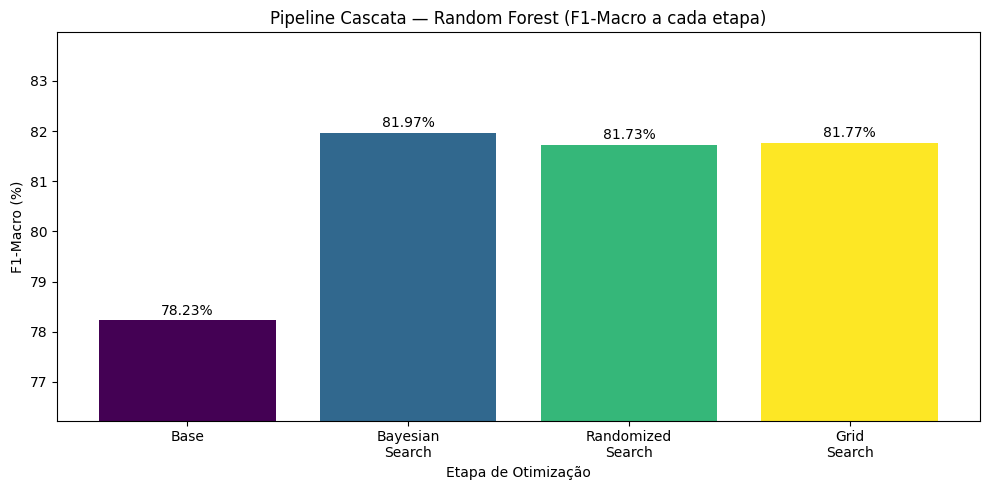

In [35]:
# Consolidando resultados do pipeline cascata — Random Forest
f1_base_rf = resultados_base['Random Forest']['f1_macro']

print('===== Random Forest — Pipeline Cascata =====')
print(f'{"Etapa":<22} {"F1-Macro":>10} {"Acurácia":>10} {"Tempo":>10}')
print('-' * 56)
print(f'{"Base (class_weight)":<22} {f1_base_rf*100:>9.2f}% {resultados_base["Random Forest"]["acc"]*100:>9.2f}% {"—":>10}')
print(f'{"1. Bayesian Search":<22} {f1_bayes_rf*100:>9.2f}% {acc_bayes_rf*100:>9.2f}% {tempo_bayes_rf:>9.1f}s')
print(f'{"2. Randomized Search":<22} {f1_random_rf*100:>9.2f}% {acc_random_rf*100:>9.2f}% {tempo_random_rf:>9.1f}s')
print(f'{"3. Grid Search":<22} {f1_grid_rf*100:>9.2f}% {acc_grid_rf*100:>9.2f}% {tempo_grid_rf:>9.1f}s')
print()
print('Parâmetros finais (Grid Search):', grid_rf.best_params_)

# Gráfico
etapas_rf = ['Base', 'Bayesian\nSearch', 'Randomized\nSearch', 'Grid\nSearch']
f1s_rf    = [f1_base_rf*100, f1_bayes_rf*100, f1_random_rf*100, f1_grid_rf*100]

plt.figure(figsize=(10, 5))
bars = plt.bar(etapas_rf, f1s_rf, color=['#440154', '#31688e', '#35b779', '#fde725'])
plt.title('Pipeline Cascata — Random Forest (F1-Macro a cada etapa)')
plt.xlabel('Etapa de Otimização')
plt.ylabel('F1-Macro (%)')
plt.ylim(min(f1s_rf) - 2, max(f1s_rf) + 2)
for bar, val in zip(bars, f1s_rf):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
             f'{val:.2f}%', ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

melhor_modelo_rf = grid_rf.best_estimator_


## Comparação Final — Decision Tree vs Random Forest

Aqui comparamos os resultados finais (após o pipeline cascata completo)
dos dois modelos, tanto em acurácia quanto em F1-Macro.

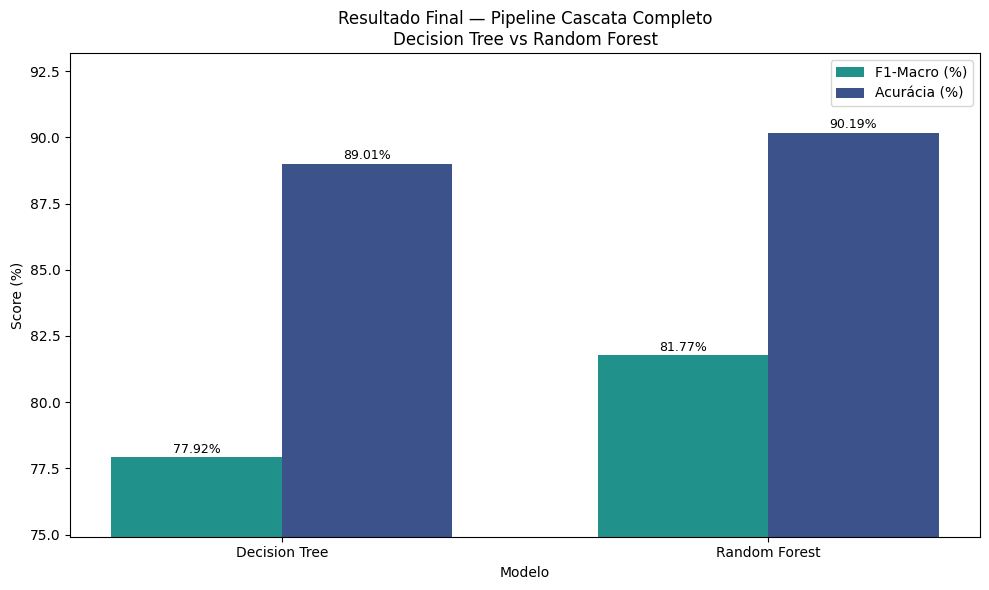

In [36]:
# ── Gráfico comparativo DT vs RF (F1-Macro) ──────────────────────────────────
modelos_comp = ['Decision Tree', 'Random Forest']
f1_finais    = [f1_grid_dt * 100, f1_grid_rf * 100]
acc_finais   = [acc_grid_dt * 100, acc_grid_rf * 100]

x = np.arange(len(modelos_comp))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, f1_finais,  width, label='F1-Macro (%)',  color='#21918c')
bars2 = ax.bar(x + width/2, acc_finais, width, label='Acurácia (%)', color='#3b528b')

ax.set_title('Resultado Final — Pipeline Cascata Completo\nDecision Tree vs Random Forest')
ax.set_xlabel('Modelo')
ax.set_ylabel('Score (%)')
ax.set_xticks(x)
ax.set_xticklabels(modelos_comp)
ax.set_ylim(min(f1_finais + acc_finais) - 3, max(f1_finais + acc_finais) + 3)
ax.legend()

for bar in bars1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)
for bar in bars2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{bar.get_height():.2f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()


### Avaliação Final por Classe — Melhor Modelo

Avaliando o melhor modelo resultante do pipeline cascata com foco nas métricas
por classe, especialmente Moderate e Severe.

Melhor modelo: Random Forest
F1-Macro final: 81.77%
Acurácia final: 90.19%

              precision    recall  f1-score   support

     Healthy       0.97      0.96      0.96     10831
        Mild       0.87      0.89      0.88      6696
    Moderate       0.65      0.67      0.66      1660
      Severe       0.81      0.74      0.77       813

    accuracy                           0.90     20000
   macro avg       0.82      0.81      0.82     20000
weighted avg       0.90      0.90      0.90     20000



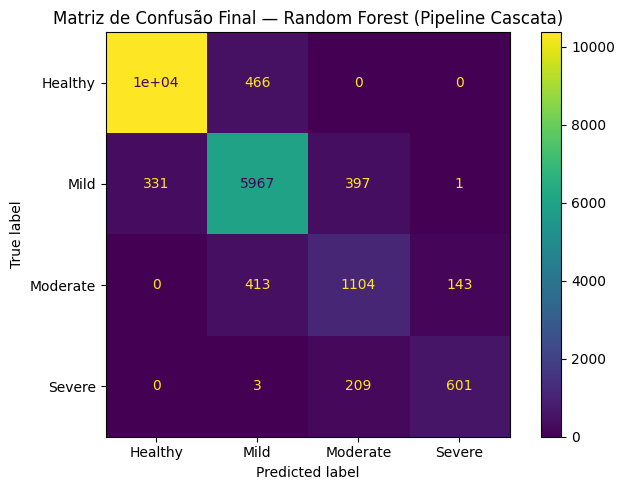

In [37]:
# Escolhe o melhor modelo com base no F1-Macro
if f1_grid_dt >= f1_grid_rf:
    melhor_nome   = 'Decision Tree'
    melhor_modelo = melhor_modelo_dt
    y_pred_final  = y_pred_grid_dt
else:
    melhor_nome   = 'Random Forest'
    melhor_modelo = melhor_modelo_rf
    y_pred_final  = y_pred_grid_rf

print(f'Melhor modelo: {melhor_nome}')
print(f'F1-Macro final: {f1_score(y_test, y_pred_final, average="macro")*100:.2f}%')
print(f'Acurácia final: {accuracy_score(y_test, y_pred_final)*100:.2f}%')
print()
print(classification_report(y_test, y_pred_final,
      target_names=['Healthy', 'Mild', 'Moderate', 'Severe']))

fig, ax = plt.subplots(figsize=(7, 5))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_final,
    display_labels=['Healthy', 'Mild', 'Moderate', 'Severe'],
    cmap='viridis', ax=ax)
ax.set_title(f'Matriz de Confusão Final — {melhor_nome} (Pipeline Cascata)')
plt.tight_layout()
plt.show()


### Análise do Resultado Final

**Melhor modelo: Random Forest (Pipeline Cascata)**

| Classe | Precisão | Recall | F1 | Suporte |
|---|---|---|---|---|
| Healthy | 0,97 | 0,96 | 0,96 | 10.831 |
| Mild | 0,87 | 0,89 | 0,88 | 6.696 |
| Moderate | 0,65 | 0,67 | 0,66 | 1.660 |
| Severe | 0,81 | 0,74 | 0,77 | 813 |
| **F1-Macro** | | | **81,77%** | |
| **Acurácia** | | | **90,19%** | |

**Por que F1-Macro é a métrica que importa aqui?**

O dataset tem 54% de casos Healthy. Um modelo que chutasse Healthy para tudo atingiria
54% de acurácia sem aprender nada. Com `class_weight='balanced'` e `scoring='f1_macro'`,
o modelo foi forçado a aprender as classes minoritárias. O resultado final confirma isso:
Moderate saiu de recall 0,46 (modelo RF base) para recall 0,67 no modelo otimizado —
um ganho de 21 pontos percentuais na classe mais difícil.

**O que o pipeline cascata trouxe de concreto?**

- O **Bayesian Search** identificou que profundidades maiores (depth=33) e mais árvores
  (251) eram a região promissora — valores bem diferentes dos defaults do sklearn.
- O **Randomized Search** refinou os parâmetros na região estreitada, ajustando
  `min_samples_split=11` e `min_samples_leaf=3`.
- O **Grid Search** executou a busca exaustiva no espaço já reduzido, confirmando
  os parâmetros finais (`depth=36, trees=176`) com custo viável.

**Sobre o custo computacional:**
O Grid Search do Random Forest levou ~1h45 sozinho. Isso reforça exatamente por que
o pipeline cascata faz sentido: sem o Bayesian e o Randomized estreitando o espaço
antes, um Grid Search sobre o espaço amplo original seria inviável computacionalmente.


## Conclusão:

### Síntese do Trabalho

Este notebook teve como objetivo prever o risco de distúrbio do sono
(`sleep_disorder_risk`) de uma pessoa com base em seus hábitos de saúde,
sono e estilo de vida, utilizando o dataset Sleep Health & Daily Performance
com 100.000 registros.

### Principais achados na Análise Exploratória

- O dataset apresenta desbalanceamento entre as classes: Healthy representa 54,2%
  dos dados, Mild 33,5%, Moderate 8,3% e Severe apenas 4,1%
- As variáveis com maior relação com o risco de sono foram:
  `stress_score`, `sleep_duration_hrs`, `sleep_quality_score` e `mental_health_condition`
- A qualidade do sono mostrou a relação mais clara entre as classes
- O consumo de cafeína antes de dormir aumenta progressivamente do Healthy ao Severe

### Sobre o Desbalanceamento e a Escolha de Métricas

O dataset tem distribuição desigual das classes (54% Healthy, 4% Severe).
Por isso, **acurácia sozinha não é suficiente** — um modelo que previsse Healthy
para tudo atingiria 54% sem aprender nada útil.

As correções aplicadas:
- `class_weight='balanced'` em todos os modelos: penaliza mais erros nas classes menores
- **F1-Macro** como métrica principal: trata todas as classes igualmente na otimização
- Avaliação por classe no relatório final: confirma que o modelo realmente detecta
  Moderate e Severe, não apenas acerta por força do desbalanceamento

O SMOTE foi testado e descartado: a abordagem de `class_weight='balanced'` se mostrou
superior em todos os 6 modelos avaliados — o oversampling sintético gerou instâncias
que não refletiram bem o padrão real dos dados.

### Pipeline Cascata de Otimização — Resultados

| Etapa | Decision Tree | Random Forest |
|---|---|---|
| Base (class_weight) | F1 76,48% | F1 78,23% |
| 1. Bayesian Search | F1 77,84% (+1,36 p.p.) | F1 81,97% (+3,74 p.p.) |
| 2. Randomized Search | F1 77,92% (+0,08 p.p.) | F1 81,73% (-0,24 p.p.) |
| 3. Grid Search | F1 77,92% (estável) | F1 81,77% (+0,04 p.p.) |

O pipeline cascata é superior à comparação isolada porque cada técnica cobre a fraqueza
da anterior: o Bayesian é eficiente mas inexato; o Randomized é rápido mas aleatório;
o Grid é preciso mas só viável num espaço pequeno. Sem as duas primeiras etapas, o
Grid Search do Random Forest sobre o espaço amplo seria computacionalmente inviável.

### Modelo Final Selecionado

**Random Forest** com parâmetros: `n_estimators=176`, `max_depth=36`,
`min_samples_leaf=3`, `min_samples_split=11`

- **F1-Macro: 81,77%** | Acurácia: 90,19%
- Healthy: F1 0,96 | Mild: F1 0,88 | Moderate: F1 0,66 | Severe: F1 0,77
- Moderate saiu de recall 0,46 (base) para 0,67 (otimizado): +21 p.p.

### Limitações e Próximos Passos

- Moderate ainda apresenta o menor F1 (0,66), sendo a classe mais difícil de prever —
  reflexo de sua posição intermediária no espectro, frequentemente confundida com Mild
- O custo computacional do pipeline cascata foi alto (~2h30 para o Random Forest):
  versões futuras podem usar early stopping ou redução de `n_estimators` para prototipagem
- Próximos experimentos: testar ADASYN (oversampling adaptativo), threshold customizado
  por classe para aumentar recall nas classes críticas, ou modelos ensemble (XGBoost, LightGBM)
